In [100]:
# Hazırlayan : Tülin Eren Proje: "Hacker News Teknoloji Depremleri Analizi"

In [88]:
# ADIM 1 — Kurulum ve veri çekme
!pip install duckdb pandas plotly scikit-learn -q

import duckdb
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

con = duckdb.connect()

# Önce hangi yılların gerçekten veri içerdiğini doğrula
aralik = con.execute("""
    SELECT year(time) AS yil, count(*) AS toplam
    FROM 's3://bauntek-bootcamp-shared/hackernews.parquet'
    WHERE type = 'story'
    GROUP BY yil
    ORDER BY yil
""").df()

print(aralik.to_string())

     yil  toplam
0   1970    1259
1   2006      50
2   2007   22869
3   2008   19758
4   2009    7801
5   2012   23738
6   2014   17168
7   2016   18187
8   2017   15585
9   2018   14698
10  2019    3408
11  2020    9426


In [89]:
# ADIM 2 — Ana veriyi çek ve olayları etiketle
import re

df = con.execute("""
    SELECT
        id,
        title,
        COALESCE(text, '') AS text,
        score,
        descendants,
        time,
        "by"
    FROM 's3://bauntek-bootcamp-shared/hackernews.parquet'
    WHERE type = 'story'
      AND title IS NOT NULL
      AND title != ''
      AND deleted IS NOT TRUE
      AND dead IS NOT TRUE
      AND year(time) IN (2007, 2008, 2009, 2012, 2014, 2016, 2017, 2018, 2019, 2020)
""").df()

df['time'] = pd.to_datetime(df['time'])
df['yil'] = df['time'].dt.year

print(f"Toplam story: {len(df):,}")
print(df['yil'].value_counts().sort_index())

Toplam story: 120,418
yil
2007    21663
2008    17004
2009     6464
2012    15401
2014    13689
2016    13436
2017    11504
2018    11128
2019     2657
2020     7472
Name: count, dtype: int64


In [90]:
# ADIM 3 — Olay etiketleme
EVENTS = {
    'Finansal Kriz 2008': [
        'financial crisis', 'lehman', 'recession', 'bailout',
        'wall street', 'stock market crash', 'subprime', 'bank collapse',
        'economic crisis', 'mortgage'
    ],
    'Bitcoin/Kripto': [
        'bitcoin', 'satoshi', 'cryptocurrency', 'btc', 'blockchain',
        'crypto', 'nakamoto', 'digital currency', 'mining bitcoin'
    ],
    'iPhone/Mobil Devrim': [
        'iphone', 'app store', 'ios', 'mobile app', 'smartphone',
        'android', 'mobile development', 'apple store'
    ],
    'Heartbleed/Güvenlik': [
        'heartbleed', 'openssl', 'shellshock', 'security breach',
        'data breach', 'vulnerability', 'zero day', 'ransomware',
        'cyber attack', 'nsa surveillance', 'snowden'
    ],
    'Facebook/Gizlilik': [
        'facebook', 'cambridge analytica', 'zuckerberg', 'gdpr',
        'data privacy', 'social media privacy', 'user data',
        'facebook scandal', 'mark zuckerberg'
    ],
    'Covid-19': [
        'covid', 'coronavirus', 'pandemic', 'lockdown', 'remote work',
        'quarantine', 'vaccine', 'wfh', 'work from home', 'social distancing'
    ],
    'GPT-3/Yapay Zeka': [
        'gpt-3', 'gpt3', 'openai', 'language model', 'transformer',
        'few-shot', 'neural text', 'generative ai', 'davinci', 'codex'
    ],
}

def label_event(title, text):
    combined = (title + ' ' + text).lower()
    for event, keywords in EVENTS.items():
        for kw in keywords:
            if kw in combined:
                return event
    return None

df['event'] = df.apply(lambda r: label_event(r['title'], r['text']), axis=1)
df_labeled = df[df['event'].notna()].copy()

print(f"Etiketlenen story: {len(df_labeled):,}")
print(df_labeled['event'].value_counts())

Etiketlenen story: 8,916
event
iPhone/Mobil Devrim    3409
Facebook/Gizlilik      3016
Bitcoin/Kripto         1128
Heartbleed/Güvenlik     845
Finansal Kriz 2008      379
Covid-19                100
GPT-3/Yapay Zeka         39
Name: count, dtype: int64


In [96]:
# ADIM 4 — GRAFİK 1: Yıllara göre olay dağılımı (Stacked Bar)
import plotly.io as pio
pio.renderers.default = 'notebook_connected'
df_labeled['yil'] = df_labeled['time'].dt.year

yil_olay = df_labeled.groupby(['yil', 'event']).size().reset_index(name='sayi')

fig1 = px.bar(
    yil_olay,
    x='yil',
    y='sayi',
    color='event',
    title='Teknoloji Depremleri — Yıllara Göre HN Aktivitesi',
    labels={'yil': 'Yıl', 'sayi': 'Story Sayısı', 'event': 'Olay'},
    template='plotly_white',
    height=500,
    color_discrete_sequence=px.colors.qualitative.Bold
)
fig1.update_layout(
    font=dict(size=13),
    legend=dict(title='Olay', x=1.01),
    bargap=0.2,
    title_font_size=18
)
fig1.show()
fig1.write_html('grafik1_yillik_aktivite.html')

In [97]:
# ADIM 5 — GRAFİK 2 (Eski stil + tüm yıllar)
import plotly.io as pio
pio.renderers.default = 'notebook_connected'

tum_yillar = list(range(2007, 2021))

pivot = df_labeled.groupby(['yil', 'event']).size().reset_index(name='sayi')
pivot_tablo = pivot.pivot(index='event', columns='yil', values='sayi')
pivot_tablo = pivot_tablo.reindex(columns=tum_yillar).fillna(0)

fig2 = px.imshow(
    pivot_tablo,
    title='Teknoloji Depremleri Isı Haritası — Story Sayıları (2007-2020)',
    labels=dict(x='Yıl', y='Olay', color='Story Sayısı'),
    color_continuous_scale='YlOrRd',
    aspect='auto',
    template='plotly_white',
    height=420,
    text_auto=True
)

fig2.update_layout(
    font=dict(size=12),
    title_font_size=15,
    xaxis=dict(tickmode='linear', dtick=1, tickangle=45),
    coloraxis_colorbar=dict(title='Story Sayısı')
)

fig2.show()
fig2.write_html('grafik2_isi_haritasi.html')

In [98]:
# ADIM 6 — GRAFİK 3: Her olaydan Top 2 story — Yatay Bar Chart
import plotly.io as pio
pio.renderers.default = 'notebook_connected'

top = (
    df_labeled
    .sort_values('score', ascending=False)
    .groupby('event')
    .head(2)
    .sort_values(['event', 'score'], ascending=[True, False])
)

top['title_kisa'] = top['title'].str[:55] + '...'
top['label'] = top['event'] + ' — ' + top['title_kisa']

fig3 = px.bar(
    top,
    x='score',
    y='label',
    color='event',
    orientation='h',
    title='Her Olaydan En Çok Upvote Alan Haberler',
    labels={'score': 'Upvote Sayısı', 'label': '', 'event': 'Olay'},
    template='plotly_white',
    height=600,
    color_discrete_sequence=px.colors.qualitative.Bold,
    text='score'
)

fig3.update_traces(textposition='outside')
fig3.update_layout(
    font=dict(size=11),
    title_font_size=16,
    showlegend=True,
    legend=dict(title='Olay', x=1.01),
    xaxis=dict(title='Upvote Sayısı'),
    yaxis=dict(autorange='reversed'),
    margin=dict(l=400)
)

fig3.show()
fig3.write_html('grafik3_top_stories.html')

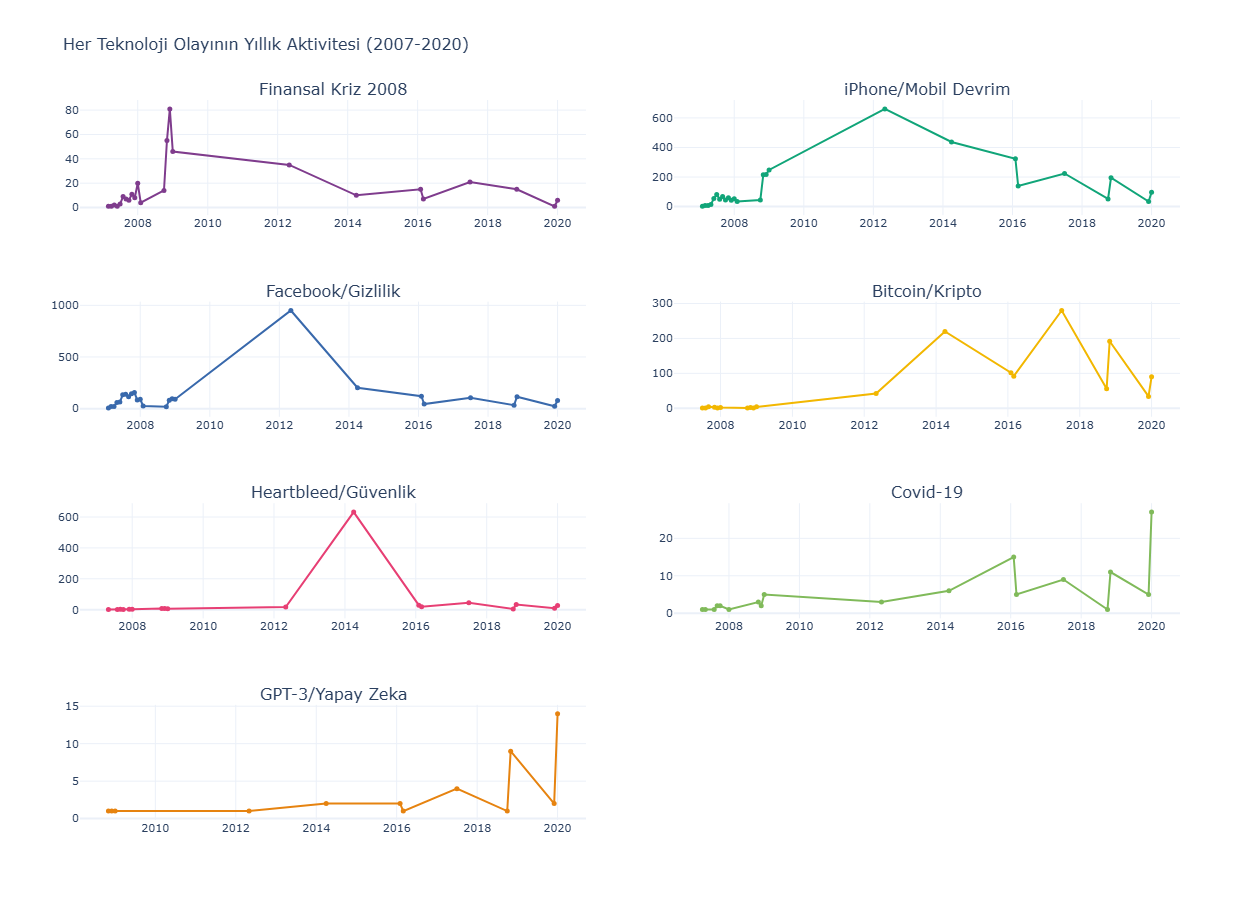

In [94]:
# ADIM 7 — GRAFİK 4 (Final): Her olay ayrı subplot

from plotly.subplots import make_subplots
import plotly.graph_objects as go

olaylar = df_labeled['event'].unique()
renkler = px.colors.qualitative.Bold

n = len(olaylar)
fig4 = make_subplots(
    rows=4, cols=2,
    subplot_titles=list(olaylar),
    shared_xaxes=False,
    vertical_spacing=0.12,
    horizontal_spacing=0.08
)

for i, (olay, renk) in enumerate(zip(olaylar, renkler)):
    row = i // 2 + 1
    col = i % 2 + 1

    alt = aylik[aylik['event'] == olay].copy()

    fig4.add_trace(
        go.Scatter(
            x=alt['ay'],
            y=alt['sayi'],
            mode='lines+markers',
            name=olay,
            line=dict(color=renk, width=2),
            marker=dict(size=5),
            showlegend=False
        ),
        row=row, col=col
    )

fig4.update_layout(
    title=dict(text='Her Teknoloji Olayının Yıllık Aktivitesi (2007-2020)', font_size=16),
    template='plotly_white',
    height=900,
    font=dict(size=11)
)

fig4.show()
fig4.write_html('grafik4_zaman_serisi.html')


In [99]:
# ADIM 8 — GRAFİK 5 (Değiştirildi): Grouped Bar — Olay Profilleri
import plotly.io as pio
pio.renderers.default = 'notebook_connected'

radar_df_melted = radar_df.melt(
    id_vars='event',
    value_vars=['toplam_story_norm', 'ort_puan_norm', 'ort_yorum_norm', 'max_puan_norm'],
    var_name='metrik',
    value_name='deger'
)

radar_df_melted['metrik'] = radar_df_melted['metrik'].map({
    'toplam_story_norm': 'Story Sayısı',
    'ort_puan_norm': 'Ort. Puan',
    'ort_yorum_norm': 'Ort. Yorum',
    'max_puan_norm': 'Max Puan'
})

fig5 = px.bar(
    radar_df_melted,
    x='metrik',
    y='deger',
    color='event',
    barmode='group',
    title='Teknoloji Olaylarının Etki Profili (Normalize 0-100)',
    labels={'metrik': 'Metrik', 'deger': 'Skor (0-100)', 'event': 'Olay'},
    template='plotly_white',
    height=500,
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig5.update_layout(
    font=dict(size=12),
    title_font_size=16,
    legend=dict(title='Olay', x=1.01),
    yaxis=dict(ticksuffix='%', range=[0, 105]),
)

fig5.show()
fig5.write_html('grafik5_profil.html')